In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

from src.curves.discount_curve import DiscountCurve
from src.curves.curve_shocks import CurveShocks

from src.instruments.fixed_rate_loan import FixedRateLoan
from src.instruments.floating_rate_loan import FloatingRateLoan
from src.instruments.interest_rate_swap import IRSwap

from src.risk.eve_engine import EVEEngine
from src.risk.nii_engine import NIIEngine

from src.behavioral.nmd_model import NMDModel

In [2]:
# convert curve into long format
def prepare_curve_for_irrbb(
        curve_df: pd.DataFrame,
        valuation_date: datetime
) -> pd.DataFrame:
    """ 
    Select closest available curve before valuation date 
    and convert historical yield curve dataset into
    single curve into long format (tenor, rate)
    """
    
    curve_df['Date'] = pd.to_datetime(curve_df['Date'])

    # step 1: keep the curve dataset before valuation date
    curve_hist = curve_df.loc[
        curve_df['Date'] <= valuation_date
    ]

    if curve_hist.empty:
        raise ValueError("No curve available before valuation date!")
    
    # step 2: pick latest available curve before valuation date
    latest_curve = curve_hist.sort_values('Date').iloc[-1].copy()

    # step 3: drop date column
    latest_curve = latest_curve.drop('Date')

    # step 4: wide into long format
    curve_long = (
            latest_curve
            .rename_axis('tenor_label')
            .reset_index(name = 'rate')
    )

    tenor_map = {
        "1M": 1/12,
        "3M": 3/12,
        "6M": 6/12,
        "1Y": 1,
        "2Y": 2,
        "5Y": 5,
        "10Y": 10,
        "30Y": 30
    }

    curve_long['tenor'] = curve_long['tenor_label'].map(tenor_map)
    curve_long = curve_long.loc[:, ['tenor', 'rate']].sort_values('tenor')
    curve_long = curve_long.rename(
        columns = {
            'tenor': 'tenor_years',
            'rate': 'zero_rate'
        }
    )
    curve_long['zero_rate'] = curve_long['zero_rate'].astype('float')

    return curve_long

In [3]:
# loading yield curve
zero_curve = pd.read_csv('../data/processed/yield_curve_clean.csv')

# initiate valuation date
valuation_date = datetime(2026, 3, 1)

# convert zero curve into long format
zero_curve_long = prepare_curve_for_irrbb(
    curve_df = zero_curve,
    valuation_date = valuation_date
)

zero_curve_long

,tenor_years,zero_rate
0,0.083333,0.0374
1,0.250000,0.0367
2,0.500000,0.0360
3,1.000000,0.0348
4,2.000000,0.0338
5,5.000000,0.0351
6,10.000000,0.0397
7,30.000000,0.0464


In [4]:
# initiate discount curve
base_dc = DiscountCurve(zero_curve_long)

# generate Basel shock scenarios
shock_engine = CurveShocks(zero_curve_long)
shocked_curves = shock_engine.generate_all_scenarios()

# shocked discount curves
shocked_dc = {
    name: DiscountCurve(curve)
    for name, curve in shocked_curves.items()
}

In [5]:
### bank balance sheet
# assets
fixed_loans = [
    FixedRateLoan(
        notional = 650000,
        start_date = '2026-03-01',
        maturity_date = '2041-03-01',
        fixed_rate = 0.054,
        payment_frequency = 'M' 
    ),
    FixedRateLoan(
        notional = 480000,
        start_date = '2026-03-01',
        maturity_date = '2046-03-01',
        fixed_rate = 0.057,
        payment_frequency = 'M' 
    )
]

floating_loans = [
    FloatingRateLoan(
        notional = 740000,
        spread = 0.012,
        maturity_years = 5,
        payments_per_year = 2
    ),
    FloatingRateLoan(
        notional = 360000,
        spread = 0.009,
        maturity_years = 3,
        payments_per_year = 4
    )
]

# swaps
hedge_swap = [
    IRSwap(
        notional = 1500000,
        fixed_rate = 0.035,
        maturity_years = 5,
        payments_per_year = 4
    )
]

# liabilities
nmd = NMDModel(
    balance = 2400000,
    product_type = 'retail_savings',
    core_ratio = 0.80,
    avg_life_years = 5,
    beta = 0.3 
)

In [6]:
# compute base EVE and NII metrics
eve_engine = EVEEngine(
    discount_curve = base_dc,
    valuation_date = valuation_date
)

nii_engine = NIIEngine(
    valuation_date = valuation_date
)

base_EVE = eve_engine.compute_eve_from_instruments(
    fixed_loans = fixed_loans,
    floating_loans = floating_loans,
    nmd_model = nmd
)

base_NII = nii_engine.compute_nii_from_instruments(
    fixed_loans = fixed_loans,
    floating_loans = floating_loans,
    nmd_model = nmd,
    discount_curve = base_dc,
    rate_shock = 0
)

print(f"Base EVE: {float(base_EVE):.2f}")
print(f"Base NII: {float(base_NII):.2f}")

Base EVE: 485037.81
Base NII: 110951.95


In [7]:
# Basel shock simulation
results = []

for scenario, shocked_curve in shocked_dc.items():

    # EVE
    eve_engine_shocked = EVEEngine(
        discount_curve = shocked_curve,
        valuation_date = valuation_date
    )

    shocked_eve = eve_engine_shocked.compute_eve_from_instruments(
        fixed_loans = fixed_loans,
        floating_loans = floating_loans,
        nmd_model = nmd
    )

    delta_eve = shocked_eve - base_EVE

    # NII
    rate_shock = (
        shocked_curve.curve.loc[
            shocked_curve.curve.tenor_years == 1,
            'zero_rate'
            ].values[0]
        - base_dc.curve.loc[
            base_dc.curve.tenor_years == 1,
            'zero_rate'
        ].values[0]
    ).round(4)

    shocked_nii = nii_engine.compute_nii_from_instruments(
        fixed_loans = fixed_loans,
        floating_loans = floating_loans,
        nmd_model = nmd,
        discount_curve = shocked_curve,
        rate_shock = rate_shock 
    )

    delta_nii = shocked_nii - base_NII

    results.append([
        scenario,
        round(float(delta_eve), 2),
        round(float(delta_nii), 2)
    ])

# IRRBB report table
irrbb_report = pd.DataFrame(
    results,
    columns = [
        'Scenario',
        'Delta_EVE',
        'Delta_NII'
    ]
).set_index('Scenario')

# Tier 1 capital check
tier1_capital = 600000

irrbb_report['EVE_ratio'] = irrbb_report['Delta_EVE'].abs() / tier1_capital
irrbb_report['Basel_Breach'] = irrbb_report['EVE_ratio'] > 0.15

irrbb_report


,Delta_EVE,Delta_NII,EVE_ratio,Basel_Breach
Scenario,,,,
parallel_up,-75024.69,7600.0,0.125041,False
parallel_down,104031.74,-7600.0,0.173386,True
short_up,-64348.55,9500.0,0.107248,False
short_down,83809.34,-9500.0,0.139682,False
steepener,15316.77,-3800.0,0.025528,False
flattener,-14259.44,3800.0,0.023766,False


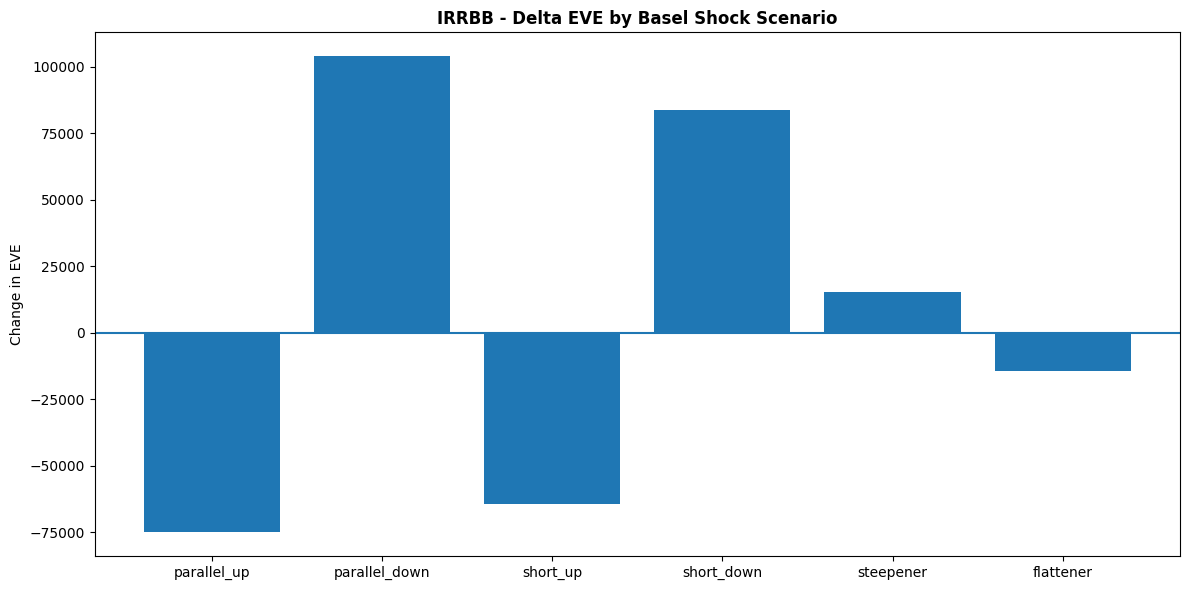

In [8]:
# plot delta_EVE under Basel shock scenarios
plt.figure(figsize=(12,6))
plt.bar(
    irrbb_report.index,
    irrbb_report['Delta_EVE']
)
plt.title('IRRBB - Delta EVE by Basel Shock Scenario', fontweight = 'bold')
plt.ylabel('Change in EVE')
plt.axhline(0)
plt.tight_layout()
plt.show()

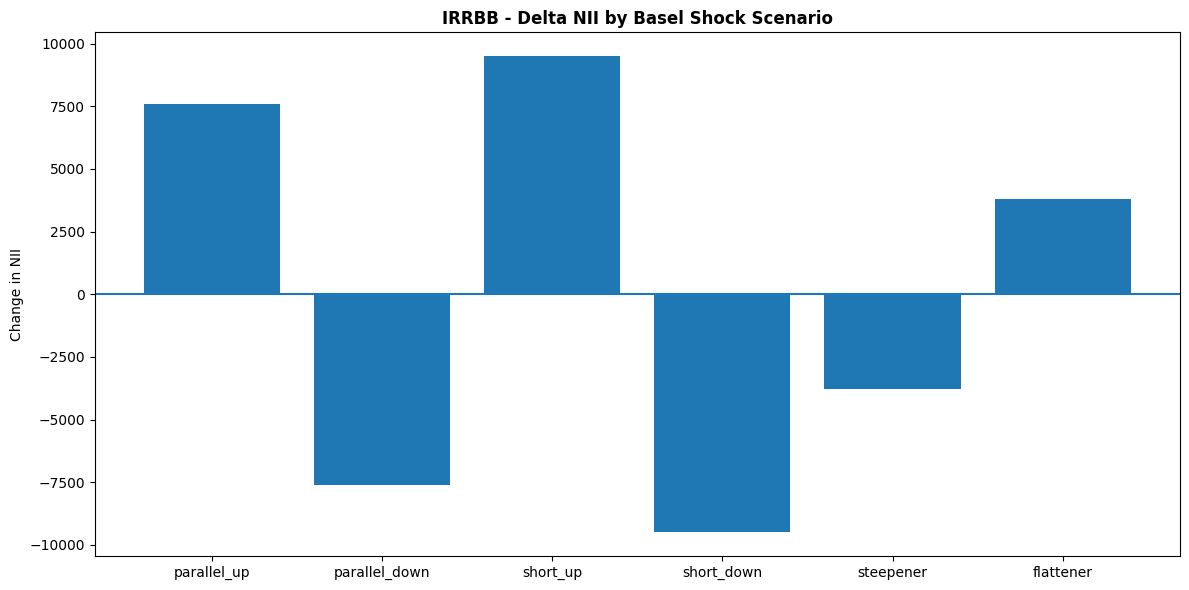

In [9]:
# plot delta_NII under Basel shock scenarios
plt.figure(figsize=(12,6))
plt.bar(
    irrbb_report.index,
    irrbb_report['Delta_NII']
)
plt.title('IRRBB - Delta NII by Basel Shock Scenario', fontweight = 'bold')
plt.ylabel('Change in NII')
plt.axhline(0)
plt.tight_layout()
plt.show()

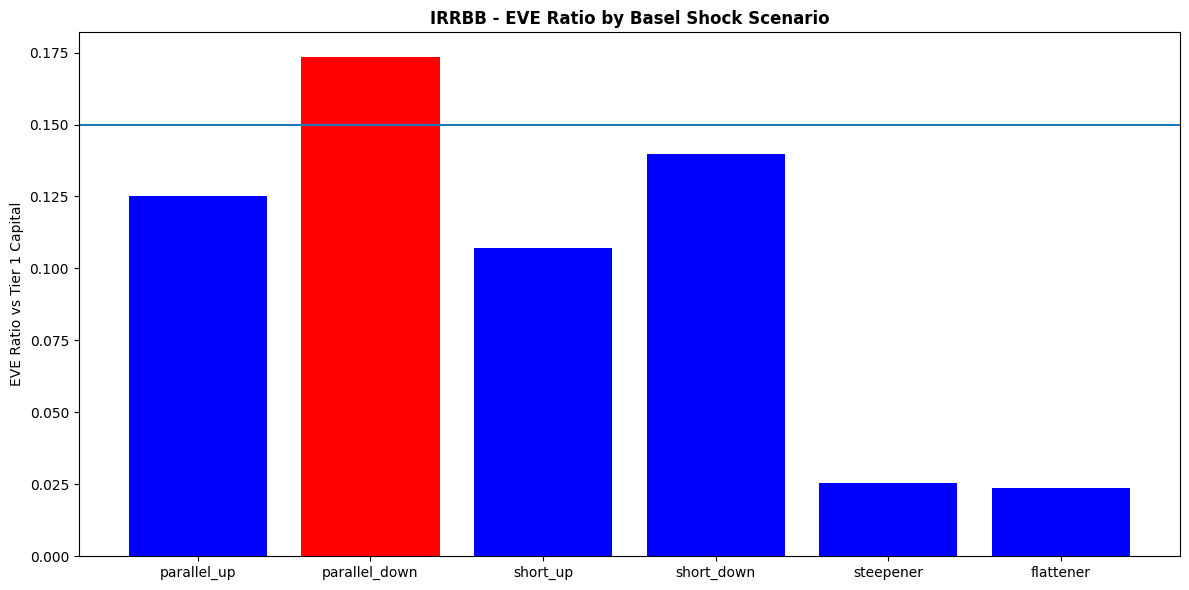

In [10]:
# plot basel outlier test under Basel shock scenarios
plt.figure(figsize=(12,6))

c = ['red' if breach else 'blue' for breach in irrbb_report['Basel_Breach']]
plt.bar(
    irrbb_report.index,
    irrbb_report['EVE_ratio'],
    color = c
)
plt.title('IRRBB - EVE Ratio by Basel Shock Scenario', fontweight = 'bold')
plt.ylabel('EVE Ratio vs Tier 1 Capital')
plt.axhline(0.15)
plt.tight_layout()
plt.show()

In [11]:
# Basel shock simulation with IR swaps
results_hedged = []

for scenario, shocked_curve in shocked_dc.items():

    # EVE
    eve_engine_shocked = EVEEngine(
        discount_curve = shocked_curve,
        valuation_date = valuation_date
    )

    shocked_eve_hedged = eve_engine_shocked.compute_eve_from_instruments(
        fixed_loans = fixed_loans,
        floating_loans = floating_loans,
        nmd_model = nmd,
        swaps = hedge_swap
    )

    delta_eve_hedged = shocked_eve_hedged - base_EVE

    # NII
    rate_shock = (
        shocked_curve.curve.loc[
            shocked_curve.curve.tenor_years == 1,
            'zero_rate'
            ].values[0]
        - base_dc.curve.loc[
            base_dc.curve.tenor_years == 1,
            'zero_rate'
        ].values[0]
    ).round(4)

    shocked_nii = nii_engine.compute_nii_from_instruments(
        fixed_loans = fixed_loans,
        floating_loans = floating_loans,
        nmd_model = nmd,
        discount_curve = shocked_curve,
        rate_shock = rate_shock 
    )

    delta_nii = shocked_nii - base_NII

    results_hedged.append([
        scenario,
        round(float(delta_eve_hedged), 2),
        round(float(delta_nii), 2)
    ])

# IRRBB report table
irrbb_report_hedged = pd.DataFrame(
    results_hedged,
    columns = [
        'Scenario',
        'Delta_EVE_hedged',
        'Delta_NII'
    ]
).set_index('Scenario')

# Tier 1 capital check
tier1_capital = 600000

irrbb_report_hedged['EVE_ratio'] = irrbb_report_hedged['Delta_EVE_hedged'].abs() / tier1_capital
irrbb_report_hedged['Basel_Breach'] = irrbb_report_hedged['EVE_ratio'] > 0.15

irrbb_report_hedged

,Delta_EVE_hedged,Delta_NII,EVE_ratio,Basel_Breach
Scenario,,,,
parallel_up,58267.98,7600.0,0.097113,False
parallel_down,-36662.89,-7600.0,0.061105,False
short_up,87052.35,9500.0,0.145087,False
short_down,-79209.92,-9500.0,0.132017,False
steepener,-39788.46,-3800.0,0.066314,False
flattener,44874.21,3800.0,0.074790,False


,Unhedged_EVE,Hedged_EVE
Scenario,,
parallel_up,-75024.69,58267.98
parallel_down,104031.74,-36662.89
short_up,-64348.55,87052.35
short_down,83809.34,-79209.92
steepener,15316.77,-39788.46
flattener,-14259.44,44874.21


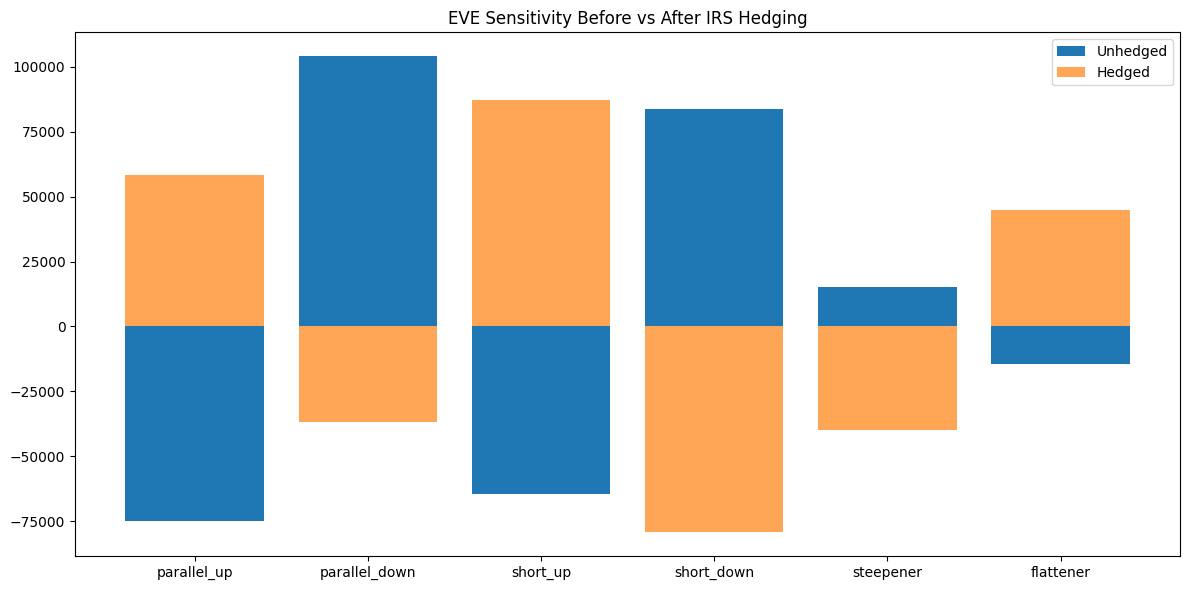

In [13]:
# comparison before vs after IR swap hedge
df_comparison = pd.DataFrame({
    'Unhedged_EVE': irrbb_report['Delta_EVE'],
    'Hedged_EVE': irrbb_report_hedged['Delta_EVE_hedged'] 
})

display(df_comparison)

# plotting EVE sensitivity before vs after IR swap hedge
plt.figure(figsize=(12, 6))
plt.bar(
    df_comparison.index,
    df_comparison['Unhedged_EVE'],
    label = 'Unhedged'
)
plt.bar(
    df_comparison.index,
    df_comparison['Hedged_EVE'],
    label = 'Hedged',
    alpha = 0.7
)
plt.legend()
plt.title('EVE Sensitivity Before vs After IRS Hedging')
plt.tight_layout()
plt.show()